# CT Global Registration

A manual registration recipe for the four configured global-validation CT volumes used by notebook 05.

## Run order

1. Run the configuration cell to locate the configured global-validation volume tree.
2. Review the four selected CT folder names and their proposed `._global.hdf5` outputs. The first selected input is the reference volume.
3. Run global registration. It estimates each moving volume's transform to the reference and writes the registered volumes, global-grid metadata, and stored transforms to the `._global.hdf5` files.
4. Optionally transform a derived dataset, such as `threshold_mask`, using one of those stored transforms.
5. Run the final visual check after at least two global files exist.

The command-line and notebook registration routes are alternatives: use one route for a cohort, then continue with the derived-dataset and validation steps below.


## Command line

Run registration from the project root with matching input and output lists. The first input is the default reference volume.

```powershell
uv run basalt-register-global `
  --inputs CT\processed\scan-a\volume-a.hdf5 CT\processed\scan-b\volume-b.hdf5 `
  --outputs CT\processed\scan-a\volume-a._global.hdf5 CT\processed\scan-b\volume-b._global.hdf5 `
  --vol-key data_masked `
  --reference-index 0 `
  --spacing-mode reference
```

Use `--spacing-mode min` to use the smallest voxel spacing across the cohort, `--no-affine-refine` to stop after rigid registration, and `--pad-mm 1.0` to pad the global grid. For the configured visual cohort, this notebook resolves original files and writes matching `._global.hdf5` outputs under the configured global-validation tree.


In [1]:
from pathlib import Path
import sys

working_directory = Path.cwd().resolve()
project_root = next(
    (
        candidate
        for candidate in (working_directory, *working_directory.parents)
        if (candidate / "pyproject.toml").is_file()
    ),
    None,
)
if project_root is None:
    raise RuntimeError("Run this notebook from within the basalt-processing project.")

source_root = project_root / "src"
if str(source_root) not in sys.path:
    sys.path.insert(0, str(source_root))

from basalt_processing.paths import load_config, resolve_path

CONFIG_PATH = project_root / "config" / "basalt.example.toml"
config = load_config(CONFIG_PATH)
paths_config = config.get("paths", {})
data_root = resolve_path(paths_config["data_root"], config.get("_config_dir"))
ct_processed_root = resolve_path(paths_config["ct_processed"], data_root)
global_registration_root = resolve_path(paths_config["ct_global_validation"], data_root)
ct_processed_root, global_registration_root


## Manual registration

First run the configuration cell above. This cell selects the four original 140 kV files corresponding to notebook 05's chosen `CT/processed` folder names and writes matching `._global.hdf5` outputs under `BagIt/output/CT/global_registered`.

Review `selected_inputs` and `selected_outputs` before enabling the call in the next cell. Keep the lists in the same order: `reference_index=0` makes the first input the fixed reference, and every other volume is resampled into its global grid. `vol_key="data_masked"` chooses the masked CT image as the registration signal.

Registration writes files and may take time, so the operation remains commented out by default. Uncomment and run it once for the selected cohort. Re-running it overwrites the chosen global outputs.


## Run global registration

The next cell builds the ordered input and output lists, but does not write files until you uncomment `align_cohort_to_global_grid(...)`. It registers each moving `data_masked` volume to the first selected input and writes the corresponding `._global.hdf5` files.

When that call completes, continue to the derived-dataset transform section below.


In [ ]:
from basalt_processing.registration import align_cohort_to_global_grid

VISUAL_CT_FOLDERS = (
    "20230208-160256", "20230209-102914", "20230209-111213", "20230209-130101",
    "20230210-093046", "20230211-131521", "20230211-185748", "20230213-093008",
    "20230213-165354", "20230215-185338", "20230215-212019", "20230216-142832",
)
SELECTED_VOLUMES_INDICES = (0, 2, 5, 8)
REGISTRATION_CT_FOLDERS = tuple(VISUAL_CT_FOLDERS[index] for index in SELECTED_VOLUMES_INDICES)
input_candidates = {
    ct_folder: sorted(
        path for path in (ct_processed_root / ct_folder).glob("*.hdf5")
        if "._global" not in path.name
    )
    for ct_folder in REGISTRATION_CT_FOLDERS
}
missing_inputs = [ct_folder for ct_folder, candidates in input_candidates.items() if len(candidates) != 1]
if missing_inputs:
    raise FileNotFoundError(
        f"Expected one original HDF5 input for each selected CT folder; check {missing_inputs} under {ct_processed_root}."
    )

selected_inputs = [input_candidates[ct_folder][0] for ct_folder in REGISTRATION_CT_FOLDERS]
selected_outputs = [
    global_registration_root / path.relative_to(ct_processed_root).with_name(path.stem + "._global.hdf5")
    for path in selected_inputs
]
for output_path in selected_outputs:
    output_path.parent.mkdir(parents=True, exist_ok=True)

# This call is intentionally not run during lightweight notebook tests.

RUN_DATASET_REGISTRATION = False

if RUN_DATASET_REGISTRATION:
    align_cohort_to_global_grid(selected_inputs, selected_outputs, vol_key="data_masked", reference_index=0, pad_mm=2.0, registration_max_voxels=256_000_000, resample_slab_depth=512)
selected_inputs, selected_outputs


## Transform a derived dataset

Run this only after registration has created the matching `._global.hdf5` file. The code reads the stored transform and global-grid metadata from that file, resamples `threshold_mask` from the original HDF5 file, and adds the result as `threshold_mask_global` to the global file.

The cell first checks for an existing registration output, so it will explain what is missing instead of attempting to open a proposed path. Set `RUN_DATASET_TRANSFORM = True` only after confirming the selected input and output pair.


In [ ]:
from basalt_processing.registration import transform_dataset_to_global_grid

# A dataset can only be transformed after its corresponding global file exists.
# That file is created by the registration call in the previous cell.
existing_transform_pairs = []
for original_inp_h5, candidate in zip(selected_inputs, selected_outputs):
    if candidate.is_file():
        existing_transform_pairs.append((original_inp_h5, candidate))

RUN_DATASET_TRANSFORM = False

if not existing_transform_pairs:
    print("No registered global file was found for the selected inputs. Run registration first.")
elif not RUN_DATASET_TRANSFORM:
    original_inp_h5, aligned_out_h5 = existing_transform_pairs[0]
    print(f"Set RUN_DATASET_TRANSFORM = True to transform {original_inp_h5.name}.")
else:
    original_inp_h5, aligned_out_h5 = existing_transform_pairs[0]
    transform_dataset_to_global_grid(
        original_inp_h5=original_inp_h5,
        aligned_out_h5=aligned_out_h5,
        dataset_key="threshold_mask",
        out_key="threshold_mask_global",
    )


## Validate the registered cohort

This final inspection uses the pre-generated global files under the configured global-validation tree. Set `VALIDATION_CT_FOLDERS` in the final cell to the hyphenated `CT/processed` folder names for the cohort you want to compare; this prevents the notebook from opening every large file under the 140 kV tree. It verifies that the selected files describe the same global origin, spacing, and size, then plots several raw axial slices at shared physical Z coordinates with one common intensity scale.

The legacy `._global_test.h5` files carry voxel size and array shape but not explicit global-grid metadata. For those files, the notebook infers the global size from the Z/Y/X array shape and uses a zero origin. It groups discovered files by this grid metadata and selects a pair from the largest compatible group. Use these raw views to assess whether structures line up. Normalized difference diagnostics belong in `05_ct_combined_volume_and_difference_visualisation.ipynb`, after this shared-grid check has passed.


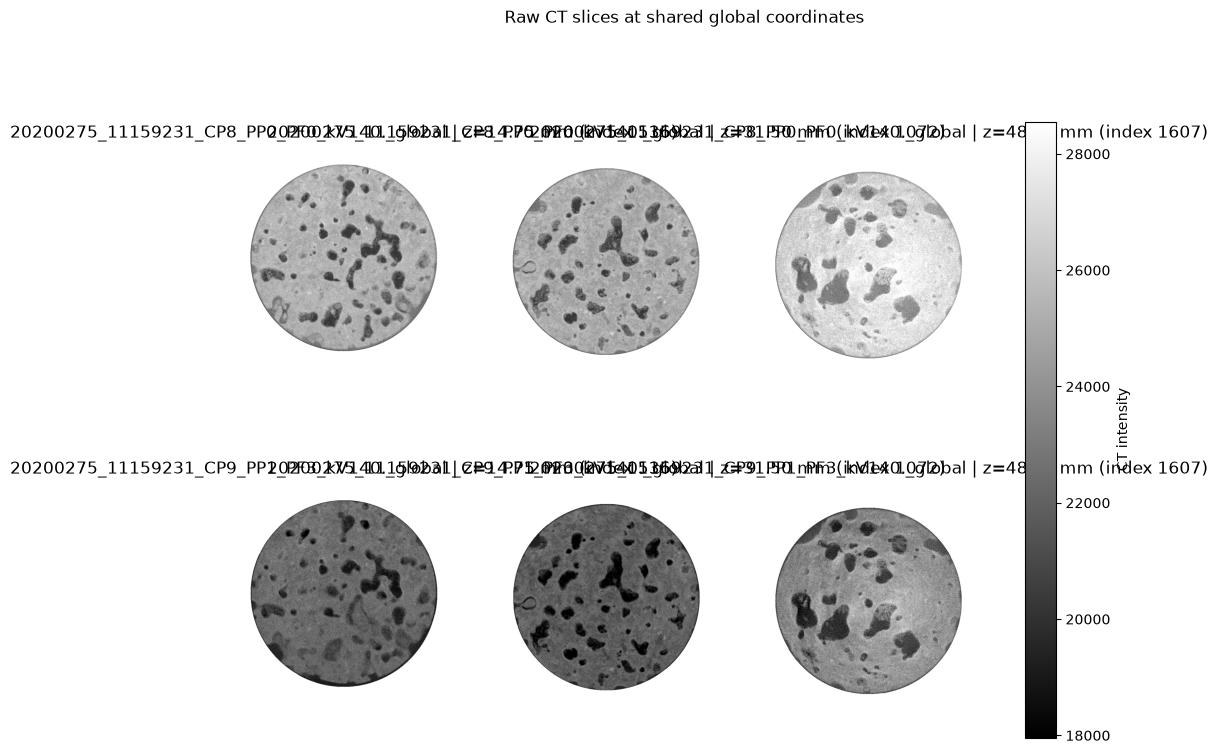

In [ ]:
import h5py
import matplotlib.pyplot as plt
import numpy as np

global_validation_root = resolve_path(paths_config["ct_global_validation"], data_root)
global_patterns = ("*._global*.h5", "*._global*.hdf5")
available_datetime_folders = sorted(
    path for path in global_validation_root.iterdir() if path.is_dir()
) if global_validation_root.exists() else []
VALIDATION_CT_FOLDERS = REGISTRATION_CT_FOLDERS # e.g. ("20230206-145700", "20230207-124626")
selected_global_folders = [
    global_validation_root / ct_folder.replace("-", "_")
    for ct_folder in VALIDATION_CT_FOLDERS
    if (global_validation_root / ct_folder.replace("-", "_")).is_dir()
]
validation_candidates = sorted(
    path
    for global_folder in selected_global_folders
    for pattern in global_patterns
    for path in global_folder.glob(pattern)
)


def global_grid_metadata(path):
    with h5py.File(path, "r") as handle:
        dataset_name = "data_masked" if "data_masked" in handle else "data"
        dataset = handle[dataset_name]
        return {
            "dataset_name": dataset_name,
            "shape_zyx": dataset.shape,
            "origin_xyz_mm": np.asarray(dataset.attrs.get("global_origin_xyz_mm", np.zeros(3, dtype=float)), dtype=float),
            "spacing_xyz_mm": np.asarray(
                dataset.attrs.get("global_spacing_xyz_mm", dataset.attrs["voxel_size"][::-1]), dtype=float
            ),
            "size_xyz": np.asarray(dataset.attrs.get("global_size_xyz", dataset.shape[::-1]), dtype=int),
        }


def read_axial_plane(path, dataset_name, z_index):
    with h5py.File(path, "r") as handle:
        return np.asarray(handle[dataset_name][z_index, :, :], dtype=float)


if not VALIDATION_CT_FOLDERS:
    print("Set VALIDATION_CT_FOLDERS to the hyphenated CT folder names you want to compare.")
    print("Available folders:", [path.name for path in available_datetime_folders])
elif len(validation_candidates) < 2:
    print(f"Add at least two global files under {global_validation_root} to run this inspection.")
else:
    metadata_by_path = {path: global_grid_metadata(path) for path in validation_candidates}
    grid_groups = {}
    for path, current in metadata_by_path.items():
        grid_key = (
            tuple(np.round(current["origin_xyz_mm"], 9)),
            tuple(np.round(current["spacing_xyz_mm"], 9)),
            tuple(current["size_xyz"]),
        )
        grid_groups.setdefault(grid_key, []).append(path)

    largest_compatible_group = max(grid_groups.values(), key=len)
    if len(largest_compatible_group) < 2:
        print("No pair of pre-generated global files shares the same inferred grid.")
    else:
        validation_inputs = sorted(largest_compatible_group)[:2]
        metadata = [metadata_by_path[path] for path in validation_inputs]
        reference = metadata[0]
        for path, current in zip(validation_inputs[1:], metadata[1:]):
            if not (
                np.allclose(current["origin_xyz_mm"], reference["origin_xyz_mm"])
                and np.allclose(current["spacing_xyz_mm"], reference["spacing_xyz_mm"])
                and np.array_equal(current["size_xyz"], reference["size_xyz"])
            ):
                raise ValueError(f"{path.name} is not on the same global grid as {validation_inputs[0].name}.")

        origin_z_mm = reference["origin_xyz_mm"][2]
        spacing_z_mm = reference["spacing_xyz_mm"][2]
        z_size = int(reference["size_xyz"][2])
        slice_indices = np.rint(np.array([0.25, 0.50, 0.75]) * (z_size - 1)).astype(int)
        slice_positions_mm = origin_z_mm + slice_indices * spacing_z_mm

        planes = {
            path: [read_axial_plane(path, current["dataset_name"], z_index) for z_index in slice_indices]
            for path, current in zip(validation_inputs, metadata)
        }
        finite_values = np.concatenate([plane[np.isfinite(plane)] for path in validation_inputs for plane in planes[path]])
        vmin, vmax = np.percentile(finite_values, [1, 99])

        fig, axes = plt.subplots(len(validation_inputs), len(slice_indices), figsize=(12, 4 * len(validation_inputs)), squeeze=False)
        for row, path in enumerate(validation_inputs):
            for column, (z_index, z_mm, plane) in enumerate(zip(slice_indices, slice_positions_mm, planes[path])):
                image = axes[row, column].imshow(plane, cmap="gray", vmin=vmin, vmax=vmax, aspect="equal")
                axes[row, column].set_title(f"{path.stem} | z={z_mm:.2f} mm (index {z_index})")
                axes[row, column].set_axis_off()
        fig.colorbar(image, ax=axes.ravel().tolist(), label="CT intensity")
        fig.suptitle("Raw CT slices at shared global coordinates", y=1.02)


